<a href="https://colab.research.google.com/github/Redcoder815/Deep_learning_phitron/blob/main/26min_max_scaler_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Min-Max Scaling (Normalization) with PyTorch

Last class, Standard Scaler asked: *"How weird are you compared with the average?"*

Today Min-Max asks a simpler question: *"Where are you between the shortest person and the tallest person?"*

We squeeze every feature onto a **0–1 ruler**. Age 18 becomes 0. Age 60 becomes 1. Salary 15,000 becomes 0. Salary 150,000 becomes 1. Same seat. Same classroom. Please stay in your chair.

$$
x' = \frac{x - \min}{\max - \min}
$$

After this, both features live in **[0, 1]**.

## 1. Setup and a first look

Same **Social Network Ads** dataset as last class. Each row is a person. The question is: did they buy (`Purchased`) after seeing an ad?

For scaling we only keep **Age** and **EstimatedSalary**.

- `User ID` is a name tag. Drop it. Normalizing a student ID does not make them taller.
- `Gender` is a category, not a number on a ruler. Leave it out of this lesson.

In [ ]:
%matplotlib inline
# If anything is missing, uncomment and run once:
# %pip install kagglehub pandas torch matplotlib

from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

torch.manual_seed(42)

path = kagglehub.dataset_download("rakeshrau/social-network-ads")
print("Path to dataset files:", path)

100%|██████████| 3.27k/3.27k [00:00<00:00, 4.58MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rakeshrau/social-network-ads/versions/1


In [ ]:
csv_path = next(Path(path).rglob("*.csv"))
print("CSV:", csv_path)

df = pd.read_csv(csv_path)
df.head()

CSV: /root/.cache/kagglehub/datasets/rakeshrau/social-network-ads/versions/1/Social_Network_Ads.csv


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Age range:    ", int(df["Age"].min()), "→", int(df["Age"].max()))
print("Salary range: ", int(df["EstimatedSalary"].min()), "→", int(df["EstimatedSalary"].max()))
print()
ratio = df["EstimatedSalary"].max() / df["Age"].max()
print(f"At the top end, salary is about {ratio:.0f}× bigger than age.")
print("Min-Max's job: squeeze both of them onto the same 0–1 tray.")

Shape: (400, 5)

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

Age range:     18 → 60
Salary range:  15000 → 150000

At the top end, salary is about 2500× bigger than age.
Min-Max's job: squeeze both of them onto the same 0–1 tray.


## 2. Why normalize?

Imagine putting **exam marks (0–100)** and **monthly salary (tens of thousands)** on one plot. Salary eats the axis. The exam might as well not exist.

A model that computes `weight * Age + weight * Salary` has the same problem. Huge numbers get huge votes — even if Age is the smarter clue.

Min-Max stretching is like taking pizza dough and pressing it onto a **square tray**. Every feature gets the same 0–1 box.

Look at the raw scatter first. Salary still hogs the axis.

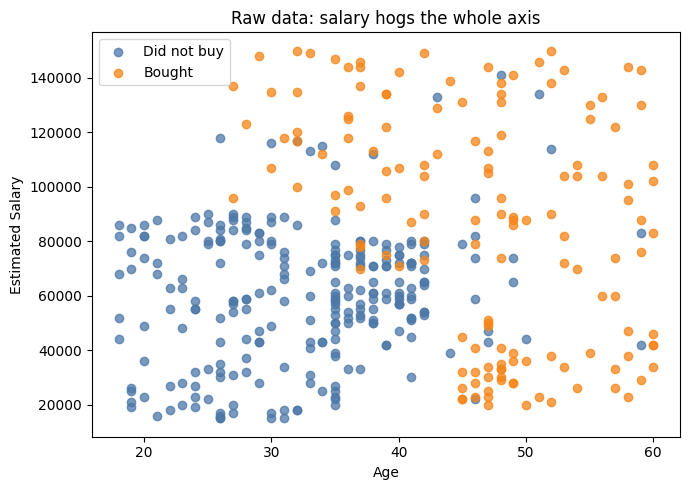

In [ ]:
bought = df["Purchased"] == 1

plt.figure(figsize=(7, 5))
plt.scatter(
    df.loc[~bought, "Age"], df.loc[~bought, "EstimatedSalary"],
    c="#4C78A8", alpha=0.75, label="Did not buy",
)
plt.scatter(
    df.loc[bought, "Age"], df.loc[bought, "EstimatedSalary"],
    c="#F58518", alpha=0.75, label="Bought",
)
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Raw data: salary hogs the whole axis")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Min-Max scaling in PyTorch

PyTorch has no built-in `MinMaxScaler`. The whole trick is five lines of math:

1. Find the **min** of each column (the shortest person).
2. Find the **max** of each column (the tallest person).
3. Subtract the min, divide by `(max - min)`.

The smallest value becomes **0**. The largest becomes **1**. Everyone else is a fraction in between.

Watch out: if one billionaire walks in (`salary = 10,000,000`), almost every real salary collapses near 0. Min-Max is polite until an outlier sits on the ruler.

In human words: *where are you between the ends of the line?*

In [ ]:
feature_cols = ["Age", "EstimatedSalary"]
X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["Purchased"].values, dtype=torch.float32)
bought_t = y_all.bool()

print("X shape:", tuple(X_all.shape))
print("First 5 rows (raw):")
print(X_all[:5])

X shape: (400, 2)
First 5 rows (raw):
tensor([[1.9000e+01, 1.9000e+04],
        [3.5000e+01, 2.0000e+04],
        [2.6000e+01, 4.3000e+04],
        [2.7000e+01, 5.7000e+04],
        [1.9000e+01, 7.6000e+04]])


In [ ]:
class TorchMinMaxScaler:
    """A tiny sklearn-style min-max scaler, but in PyTorch."""

    def __init__(self):
        self.min_ = None
        self.max_ = None
        self.scale_ = None

    def fit(self, X):
        self.min_ = X.amin(dim=0)
        self.max_ = X.amax(dim=0)
        self.scale_ = self.max_ - self.min_
        # A frozen column has max == min. Don't divide by zero.
        self.scale_ = torch.where(self.scale_ == 0, torch.ones_like(self.scale_), self.scale_)
        return self

    def transform(self, X):
        return (X - self.min_) / self.scale_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# Demo on ALL rows first, so we can see the magic.
# The honest way is train-only. That's the next section.
demo_scaler = TorchMinMaxScaler()
X_demo = demo_scaler.fit_transform(X_all)

print("Learned min:", [round(v, 2) for v in demo_scaler.min_.tolist()])
print("Learned max:", [round(v, 2) for v in demo_scaler.max_.tolist()])
print()
print("First 5 rows (scaled to 0–1):")
print(X_demo[:5])

Learned min: [18.0, 15000.0]
Learned max: [60.0, 150000.0]

First 5 rows (scaled to 0–1):
tensor([[0.0238, 0.0296],
        [0.4048, 0.0370],
        [0.1905, 0.2074],
        [0.2143, 0.3111],
        [0.0238, 0.4519]])


In [ ]:
print("After scaling — min of each column (want ~0):", X_demo.amin(dim=0).tolist())
print("After scaling — max of each column (want ~1):", X_demo.amax(dim=0).tolist())
print()
print("Both features now sit on the same 0–1 tray. Please stay in your seat.")

After scaling — min of each column (want ~0): [0.0, 0.0]
After scaling — max of each column (want ~1): [1.0, 1.0]

Both features now sit on the same 0–1 tray. Please stay in your seat.


## 4. Before vs after (the projector slide)

Left: a stretched sausage. Right: a box in **[0, 1] × [0, 1]**.

Blue = did not buy. Orange = bought.

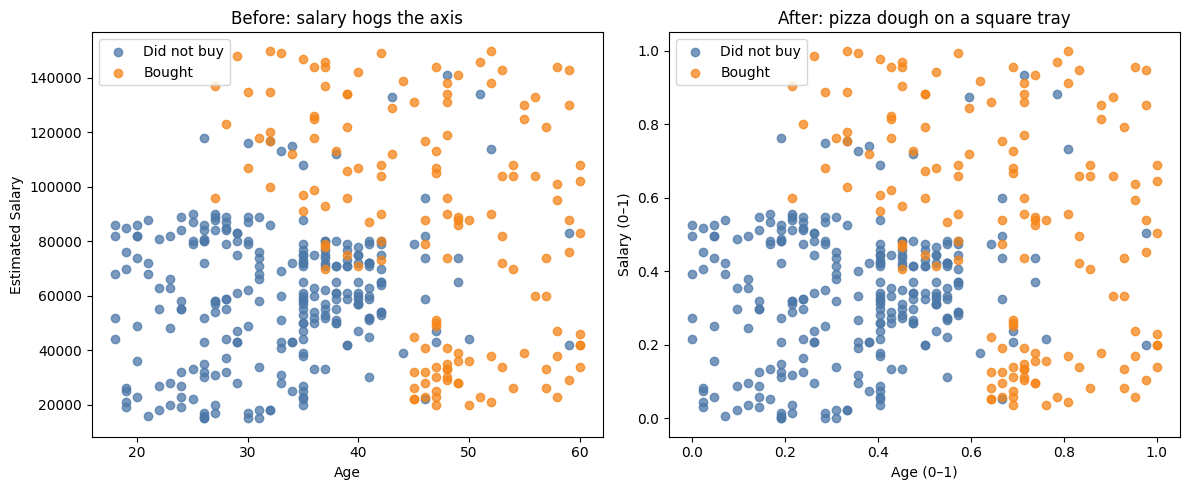

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    X_all[~bought_t, 0], X_all[~bought_t, 1],
    c="#4C78A8", alpha=0.75, label="Did not buy",
)
axes[0].scatter(
    X_all[bought_t, 0], X_all[bought_t, 1],
    c="#F58518", alpha=0.75, label="Bought",
)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Estimated Salary")
axes[0].set_title("Before: salary hogs the axis")
axes[0].legend()

axes[1].scatter(
    X_demo[~bought_t, 0], X_demo[~bought_t, 1],
    c="#4C78A8", alpha=0.75, label="Did not buy",
)
axes[1].scatter(
    X_demo[bought_t, 0], X_demo[bought_t, 1],
    c="#F58518", alpha=0.75, label="Bought",
)
axes[1].set_xlabel("Age (0–1)")
axes[1].set_ylabel("Salary (0–1)")
axes[1].set_title("After: pizza dough on a square tray")
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

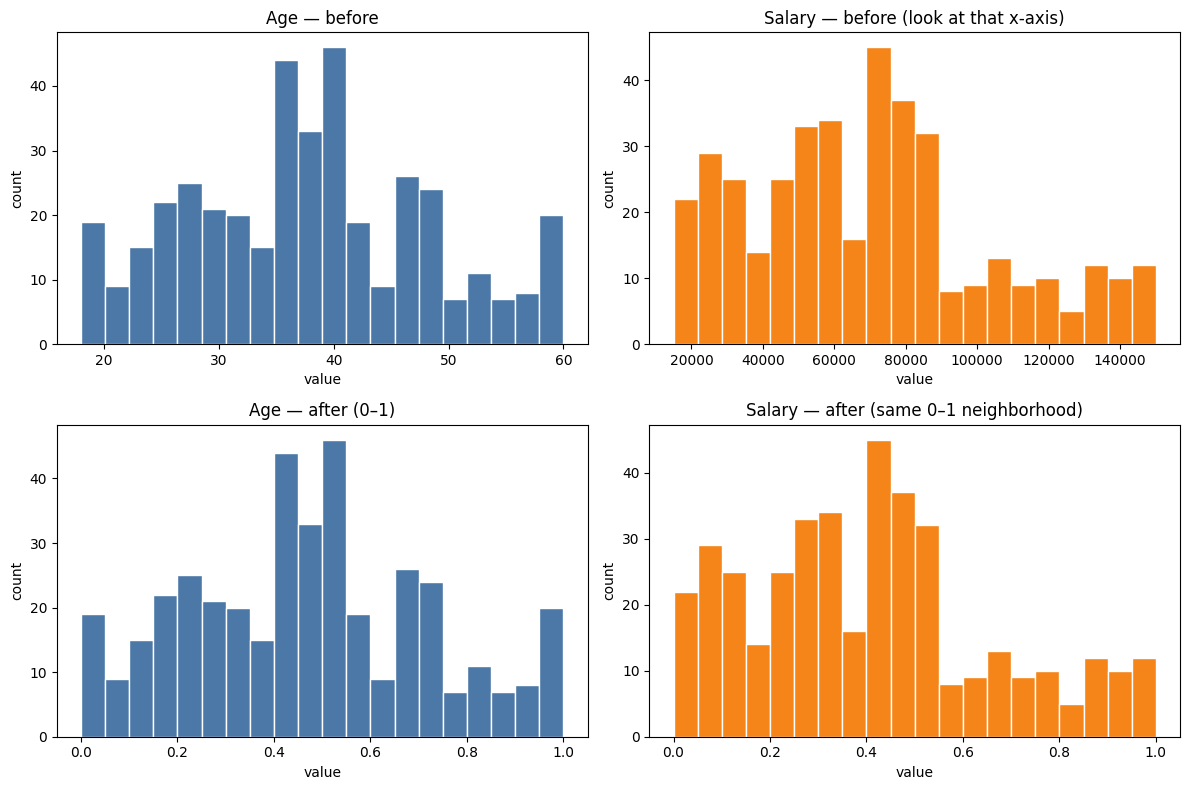

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(X_all[:, 0].numpy(), bins=20, color="#4C78A8", edgecolor="white")
axes[0, 0].set_title("Age — before")

axes[0, 1].hist(X_all[:, 1].numpy(), bins=20, color="#F58518", edgecolor="white")
axes[0, 1].set_title("Salary — before (look at that x-axis)")

axes[1, 0].hist(X_demo[:, 0].numpy(), bins=20, color="#4C78A8", edgecolor="white")
axes[1, 0].set_title("Age — after (0–1)")

axes[1, 1].hist(X_demo[:, 1].numpy(), bins=20, color="#F58518", edgecolor="white")
axes[1, 1].set_title("Salary — after (same 0–1 neighborhood)")

for ax in axes.ravel():
    ax.set_xlabel("value")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

## 5. Fit on train only (don't cheat)

If you compute min and max on **all 400 people**, the test set has already leaked into the homework.

That's like peeking at the exam, then acting surprised you scored well.

**Rule:** `fit` on train. `transform` train **and** test with those same numbers.

The test min/max will be *near* 0 and 1, not forced to them. A test person can even land a little below 0 or above 1 if they are younger or richer than anyone in train. That's honest, not a bug.

In [ ]:
n = X_all.shape[0]
perm = torch.randperm(n)
train_size = int(0.8 * n)

train_idx = perm[:train_size]
test_idx = perm[train_size:]

X_train_raw = X_all[train_idx]
X_test_raw = X_all[test_idx]
y_train = y_all[train_idx]
y_test = y_all[test_idx]

scaler = TorchMinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)  # same min/max as train. No peeking.

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("Train min used:", [round(v, 2) for v in scaler.min_.tolist()])
print("Train max used:", [round(v, 2) for v in scaler.max_.tolist()])
print("Train after: min", X_train.amin(dim=0).tolist(), "max", X_train.amax(dim=0).tolist())
print("Test  after: min", X_test.amin(dim=0).tolist(), "max", X_test.amax(dim=0).tolist())
print()
print("Train is forced to 0 and 1. Test is close, not forced. That's honest.")
print("The test people were not in the class photo.")

Train size: 320 | Test size: 80
Train min used: [18.0, 15000.0]
Train max used: [60.0, 150000.0]
Train after: min [0.0, 0.0] max [1.0, 1.0]
Test  after: min [0.02380952425301075, 0.014814814552664757] max [1.0, 1.0]

Train is forced to 0 and 1. Test is close, not forced. That's honest.
The test people were not in the class photo.


## 6. Same tiny model, two worlds

One logistic regression. Two feature versions. Same learning rate, same epochs.

`nn.Linear(2, 1)` plus `BCEWithLogitsLoss` is just:

`score = w_age * Age + w_salary * Salary + bias`

If salary is still yelling, one gradient step can overshoot. Loss goes to infinity, and we all pretend we meant to do that.

In [ ]:
def train_logreg(X_tr, y_tr, X_te, y_te, epochs=200, lr=0.1, label=""):
    torch.manual_seed(42)
    model = nn.Linear(2, 1)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    y_tr = y_tr.view(-1, 1)
    y_te = y_te.view(-1, 1)
    exploded = False
    last_loss = None

    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr), y_tr)
        last_loss = loss.item()
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"{label} epoch {epoch}: loss exploded. Salary brought a wrecking ball.")
            exploded = True
            break
        loss.backward()
        opt.step()
        if epoch in (1, 50, 100, epochs):
            print(f"{label} epoch {epoch:3d}  loss={loss.item():.4f}")

    def accuracy(X, y):
        if exploded:
            return float("nan")
        with torch.no_grad():
            preds = (torch.sigmoid(model(X)) >= 0.5).float()
            return (preds == y).float().mean().item()

    train_acc = accuracy(X_tr, y_tr)
    test_acc = accuracy(X_te, y_te)
    weights = model.weight.detach().flatten().tolist()
    bias = model.bias.detach().item()

    print(f"{label} final loss={last_loss}")
    print(f"{label} train acc={train_acc:.3f}  test acc={test_acc:.3f}")
    print(f"{label} weights  Age={weights[0]:.4f}  Salary={weights[1]:.4f}  bias={bias:.4f}")
    return model

In [ ]:
print("=== Unscaled (0–1? never heard of it) ===")
model_raw = train_logreg(X_train_raw, y_train, X_test_raw, y_test, label="unscaled")

=== Unscaled (0–1? never heard of it) ===
unscaled epoch   1  loss=22179.6406
unscaled epoch  50  loss=9370726.0000
unscaled epoch 100  loss=101298928.0000
unscaled epoch 200  loss=107327976.0000
unscaled final loss=107327976.0
unscaled train acc=0.634  test acc=0.675
unscaled weights  Age=0.8938  Salary=-390.0380  bias=-1.8532


In [ ]:
print("=== Min-Max scaled (both features in [0, 1]) ===")
model_scaled = train_logreg(X_train, y_train, X_test, y_test, label="minmax  ")

What to point at in class:

- **Unscaled** often explodes, or the salary weight stays tiny because the numbers are huge.
- **Min-Max** trains like a normal person. Loss goes down. Accuracy goes up.
- Same model. Same learning rate. The only change was squeezing both features onto a 0–1 tray.

## Recap

- **Min-Max scaling** is `(x - min) / (max - min)`. After it, values live in **[0, 1]**.
- We needed it because **Age** and **Salary** live in different universes. Salary shouts; Age whispers.
- **Fit on train only.** Transform the test set with the train min and max. Test can drift a little outside [0, 1]. That's honest.
- Do not scale IDs or categories. `User ID` is a sticker. `Gender` is a label.
- vs **Standard Scaler**: mean/std, can go negative, less scared of one wild outlier. Min-Max is bounded, and one billionaire can squash the rest of the class.
- In PyTorch you write this yourself. Five lines. That's the whole trick.